In [2]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================

#run once to install dependencies
!pip install -q numpy transformers==4.40.0 datasets==2.19.0 accelerate==0.29.3 pandas scikit-learn

^C


In [28]:
# ============================================================
# CELL 2: Imports and device setup
# ============================================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Hugging Face imports
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    pipeline
)
from datasets import load_dataset

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ All imports successful!")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB

✅ All imports successful!


In [29]:
# ============================================================
# CELL 3: Load Dataset
# ============================================================

# Load full
full_dataset = load_dataset("csv" , data_files="https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv")
print(f"Full dataset: {full_dataset}")
print(f"\nTrain size: {len(full_dataset['train'])}")





Full dataset: DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet'],
        num_rows: 24783
    })
})

Train size: 24783


In [30]:
# ============================================================
# CELL 4: split into train and test
# ============================================================


# First split off test from the 'train' split of the DatasetDict
split1 = full_dataset['train'].train_test_split(test_size=0.1, seed=42)        # 90/10

# Then split the new 'train' into train/val
split2 = split1["train"].train_test_split(test_size=0.1, seed=42)  # 90/10 of remaining

train_dataset = split2["train"]
val_dataset = split2["test"]
test_dataset = split1["test"]

print(f"\n📊 Working subsets:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val:   {len(val_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples")


📊 Working subsets:
  Train: 20073 samples
  Val:   2231 samples
  Test:  2479 samples


In [31]:
# ============================================================
# CELL 5: Raw dataset info and first few examples
# ============================================================

print("Dataset features:")
print(train_dataset.features)

print("\nFirst 5 samples from the training dataset:")
for i, example in enumerate(train_dataset.select(range(5))):
    print(f"Sample {i+1}:")
    print(f"  Tweet: {example['tweet']}")
    print(f"  Class: {example['class']} (0=hate speech, 1=offensive language, 2=neither)")
    print("--------------------------------------------------")




Dataset features:
{'Unnamed: 0': Value(dtype='int64', id=None), 'count': Value(dtype='int64', id=None), 'hate_speech': Value(dtype='int64', id=None), 'offensive_language': Value(dtype='int64', id=None), 'neither': Value(dtype='int64', id=None), 'class': Value(dtype='int64', id=None), 'tweet': Value(dtype='string', id=None)}

First 5 samples from the training dataset:
Sample 1:
  Tweet: RT @almostkanye: RT @Resolutionary_: if Crabtree woulda caught that over Sherman for the game y'all woulda said Sherman trash &amp; he got what&#8230;
  Class: 2 (0=hate speech, 1=offensive language, 2=neither)
--------------------------------------------------
Sample 2:
  Tweet: @ZakSitton lol cracker
  Class: 1 (0=hate speech, 1=offensive language, 2=neither)
--------------------------------------------------
Sample 3:
  Tweet: Why is Baltimore so damn ghetto &#128514;
  Class: 1 (0=hate speech, 1=offensive language, 2=neither)
--------------------------------------------------
Sample 4:
  Tweet: @Mana

In [32]:
# ============================================================
# CELL 6: Clean Text
# ============================================================
import re

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove HTML entities (e.g., &#8230;)
    text = re.sub(r'&amp;#\d+;', '', text)
    # Remove special characters and punctuation, keep alphanumeric and spaces
    text = re.sub(r'[^\w\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to the 'tweet' column of all datasets
train_dataset = train_dataset.map(lambda examples: {'tweet': clean_text(examples['tweet'])})
val_dataset = val_dataset.map(lambda examples: {'tweet': clean_text(examples['tweet'])})
test_dataset = test_dataset.map(lambda examples: {'tweet': clean_text(examples['tweet'])})

print("Text cleaning applied to train, validation, and test datasets.")

# Display first few cleaned samples from the training dataset
print("\nFirst 5 cleaned samples from the training dataset:")
for i, example in enumerate(train_dataset.select(range(5))):
    print(f"Sample {i+1}:")
    print(f"  Cleaned Tweet: {example['tweet']}")
    print("--------------------------------------------------")


Text cleaning applied to train, validation, and test datasets.

First 5 cleaned samples from the training dataset:
Sample 1:
  Cleaned Tweet: rt rt if crabtree woulda caught that over sherman for the game yall woulda said sherman trash amp he got what
--------------------------------------------------
Sample 2:
  Cleaned Tweet: lol cracker
--------------------------------------------------
Sample 3:
  Cleaned Tweet: why is baltimore so damn ghetto
--------------------------------------------------
Sample 4:
  Cleaned Tweet: i smiled first and then you mugged so of course ima mugg back cant bitch out lol
--------------------------------------------------
Sample 5:
  Cleaned Tweet: you bad little bitch
--------------------------------------------------


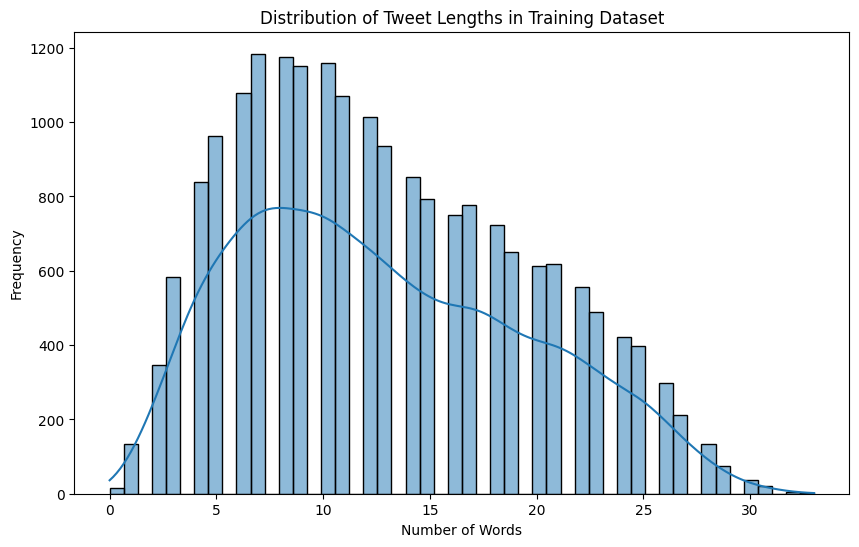

In [ ]:
# ============================================================
# CELL 7: Analyze tweet lengths
# ============================================================

tweet_lengths = [len(example['tweet'].split()) for example in train_dataset]

plt.figure(figsize=(10, 6))
sns.histplot(tweet_lengths, bins=50, kde=True)
plt.title('Distribution of Tweet Lengths in Training Dataset')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


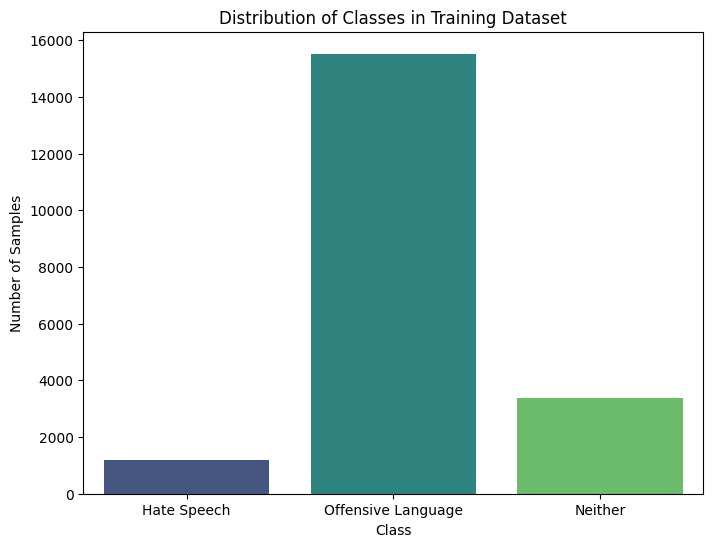

In [ ]:
# ============================================================
# CELL 8: Get class distribution
# ============================================================

class_counts = {}
for example in train_dataset:
    label = example['class']
    class_counts[label] = class_counts.get(label, 0) + 1

# Sort by class label for consistent plotting
sorted_class_counts = dict(sorted(class_counts.items()))

labels = ['Hate Speech', 'Offensive Language', 'Neither']
counts = [sorted_class_counts.get(0, 0), sorted_class_counts.get(1, 0), sorted_class_counts.get(2, 0)]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=counts, palette='viridis')
plt.title('Distribution of Classes in Training Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()


In [ ]:
# ============================================================
# CELL 9: Prepare data for TF-IDF and modeling
# ============================================================

train_df = train_dataset.to_pandas()
val_df = val_dataset.to_pandas()
test_df = test_dataset.to_pandas()

X_train_text = train_df['tweet']
y_train = train_df['class']

X_val_text = val_df['tweet']
y_val = val_df['class']

X_test_text = test_df['tweet']
y_test = test_df['class']

print("Shape of X_train_text:", X_train_text.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val_text:", X_val_text.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test_text:", X_test_text.shape)
print("Shape of y_test:", y_test.shape)

print("\n✅ Data preparation for TF-IDF completed!")

Shape of X_train_text: (20073,)
Shape of y_train: (20073,)
Shape of X_val_text: (2231,)
Shape of y_val: (2231,)
Shape of X_test_text: (2479,)
Shape of y_test: (2479,)

✅ Data preparation for TF-IDF completed!


In [ ]:
# ============================================================
# CELL 10: Build Pipeline and GridSearchCV
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create a TF-IDF Vectorizer object
tfidf = TfidfVectorizer()

# Create a Logistic Regression object
lr = LogisticRegression(random_state=42)

# Build a Pipeline
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('lr', lr)
])

# Define a parameter grid for GridSearchCV
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_features': [5000, 10000, None],
    'lr__C': [0.1, 1.0, 10.0],
    'lr__solver': ['liblinear', 'saga'],
    'lr__max_iter': [1000] # Increased max_iter for convergence
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=1  # Changed from -1 to 1 to avoid BrokenProcessPool error
)

# Fit GridSearchCV to the training data
print("\n🚀 Starting GridSearchCV...")
grid_search.fit(X_train_text, y_train)

# Print the best parameters and best score
print("\n✅ GridSearchCV completed!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best weighted F1-score: {grid_search.best_score_:.4f}")


🚀 Starting GridSearchCV...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.8s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.6s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.6s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   1.2s
[CV] END lr__C=0.1, lr__max_iter=1000, lr__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 3)


🚀 Evaluating best model on Validation Set...

Validation Accuracy: 0.8974
Validation F1-score (weighted): 0.8897

Validation Classification Report:

                    precision    recall  f1-score   support

       Hate Speech       0.44      0.24      0.31       128
Offensive Language       0.93      0.95      0.94      1739
           Neither       0.83      0.88      0.85       364

          accuracy                           0.90      2231
         macro avg       0.73      0.69      0.70      2231
      weighted avg       0.89      0.90      0.89      2231



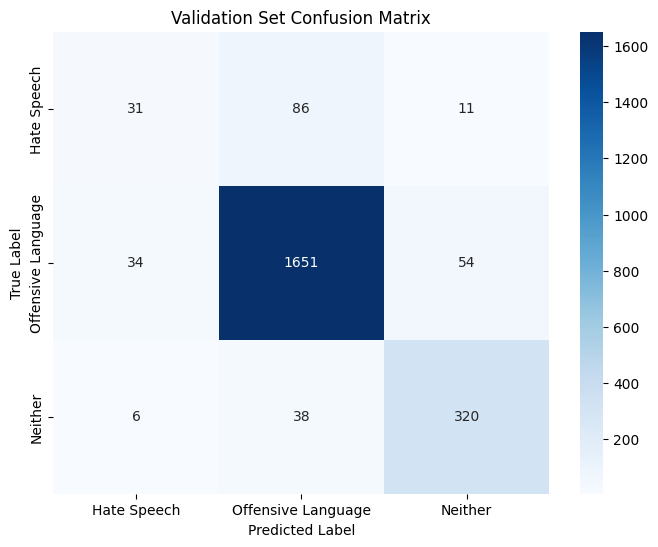


🚀 Evaluating best model on Test Set...

Test Accuracy: 0.9024
Test F1-score (weighted): 0.8959

Test Classification Report:

                    precision    recall  f1-score   support

       Hate Speech       0.45      0.26      0.33       130
Offensive Language       0.93      0.95      0.94      1930
           Neither       0.85      0.87      0.86       419

          accuracy                           0.90      2479
         macro avg       0.74      0.70      0.71      2479
      weighted avg       0.89      0.90      0.90      2479



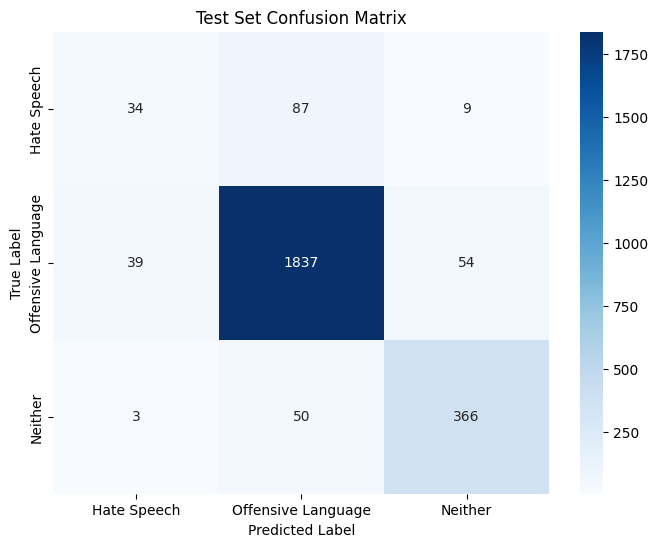


✅ Model evaluation on validation and test sets completed!


In [ ]:
# ============================================================
# CELL 11: Evaluate best model on validation and test sets
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate on Validation Set
print("\n🚀 Evaluating best model on Validation Set...")
y_val_pred = best_model.predict(X_val_text)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1-score (weighted): {val_f1:.4f}")
print("\nValidation Classification Report:\n")
print(classification_report(y_val, y_val_pred, target_names=['Hate Speech', 'Offensive Language', 'Neither']))

# Plot Confusion Matrix for Validation Set
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hate Speech', 'Offensive Language', 'Neither'],
            yticklabels=['Hate Speech', 'Offensive Language', 'Neither'])
plt.title('Validation Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Evaluate on Test Set
print("\n🚀 Evaluating best model on Test Set...")
y_test_pred = best_model.predict(X_test_text)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test F1-score (weighted): {test_f1:.4f}")
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=['Hate Speech', 'Offensive Language', 'Neither']))

# Plot Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hate Speech', 'Offensive Language', 'Neither'],
            yticklabels=['Hate Speech', 'Offensive Language', 'Neither'])
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n✅ Model evaluation on validation and test sets completed!")

In [ ]:
# ============================================================
# CELL 12: Clean up base model before fine-tuning
# ============================================================
# Free GPU memory
del best_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("✅ Base model freed from GPU memory")

✅ Base model freed from GPU memory


In [ ]:
# ============================================================
# CELL 13: Tokenize the full dataset
# ============================================================
MODEL_NAME = 'distilbert-base-uncased'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256

def tokenize_function(examples):
    """Tokenize a batch of examples."""
    return tokenizer(
        examples['tweet'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Apply tokenization to all splits
print("Tokenizing datasets...")
train_tokenized = train_dataset.map(tokenize_function, batched=True, batch_size=256)
val_tokenized = val_dataset.map(tokenize_function, batched=True, batch_size=256)
test_tokenized = test_dataset.map(tokenize_function, batched=True, batch_size=256)

print(f"\n✅ Tokenization complete!")
print(f"Train columns: {train_tokenized.column_names}")
print(f"Sample input_ids length: {MAX_LENGTH} (padded to max_length)")

Tokenizing datasets...


Map:   0%|          | 0/2231 [00:00<?, ? examples/s]


✅ Tokenization complete!
Train columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'input_ids', 'attention_mask']
Sample input_ids length: 256 (padded to max_length)


In [ ]:
# ============================================================
# CELL 14: Create DataLoaders
# ============================================================

from torch.utils.data import TensorDataset

def hf_to_tensordataset(hf_dataset):
    """Convert a Hugging Face dataset to a PyTorch TensorDataset."""
    data = hf_dataset.to_dict()
    input_ids = torch.tensor(data['input_ids'])
    attention_mask = torch.tensor(data['attention_mask'])
    labels = torch.tensor(data['class']) 
    return TensorDataset(input_ids, attention_mask, labels)

train_ds = hf_to_tensordataset(train_tokenized)
val_ds = hf_to_tensordataset(val_tokenized)
test_ds = hf_to_tensordataset(test_tokenized)

BATCH_SIZE = 16  # Small for free Colab GPU memory

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f"\nBatch contents: {len(sample_batch)} tensors (input_ids, attention_mask, labels)")
print(f"  input_ids:      {sample_batch[0].shape}")
print(f"  attention_mask:  {sample_batch[1].shape}")
print(f"  labels:          {sample_batch[2].shape}")

Batch size: 16
Train batches: 1255
Val batches: 140
Test batches: 155

Batch contents: 3 tensors (input_ids, attention_mask, labels)
  input_ids:      torch.Size([16, 256])
  attention_mask:  torch.Size([16, 256])
  labels:          torch.Size([16])


In [ ]:
# ============================================================
# CELL 15: Load classification model and configure optimizer
# ============================================================


model_name = 'distilbert-base-uncased' 
num_labels = 3 

# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels  # Use the correct number of labels
)
model.to(device)

# Print model structure summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
# The base DistilBERT model has ~66,955,000 parameters. For num_labels=3, it should be slightly more.
# Calculate actual base parameters without classification head for accurate comparison if needed.
# For now, print difference to see added parameters.
print(f"Classification head adds: ~{(total_params - 66_362_880):,} parameters")

# Optimizer — AdamW with weight decay (standard for transformers)
LEARNING_RATE = 2e-5  # Small LR for fine-tuning (don't destroy pre-trained weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

print(f"\nOptimizer: AdamW")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: 0.01")
print(f"\n💡 LR=2e-5 is standard for fine-tuning transformers.")
print(f"   Too high → destroys pre-trained knowledge (catastrophic forgetting)")
print(f"   Too low → barely learns the new task")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,955,779
Trainable parameters: 66,955,779
Classification head adds: ~592,899 parameters

Optimizer: AdamW
Learning rate: 2e-05
Weight decay: 0.01

💡 LR=2e-5 is standard for fine-tuning transformers.
   Too high → destroys pre-trained knowledge (catastrophic forgetting)
   Too low → barely learns the new task


In [ ]:
# ============================================================
# CELL 16: Training loop
# ============================================================

NUM_EPOCHS = 3

# Storage for metrics
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("=" * 60)
print("FINE-TUNING DistilBERT")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (input_ids, attention_mask, labels) in enumerate(train_loader):
        # Move to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Track metrics
        train_loss_total += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

        # Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_total / len(train_loader)
    train_acc = train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_loss_total = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            val_loss_total += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss_total / len(val_loader)
    val_acc = val_correct / val_total

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n📊 Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 60)

print("\n✅ Training complete!")

FINE-TUNING DistilBERT
  Epoch 1 | Batch 50/1255 | Loss: 0.4135
  Epoch 1 | Batch 100/1255 | Loss: 0.0741
  Epoch 1 | Batch 150/1255 | Loss: 0.2180
  Epoch 1 | Batch 200/1255 | Loss: 0.1926
  Epoch 1 | Batch 250/1255 | Loss: 0.0884
  Epoch 1 | Batch 300/1255 | Loss: 0.2438
  Epoch 1 | Batch 350/1255 | Loss: 0.1066
  Epoch 1 | Batch 400/1255 | Loss: 0.0665
  Epoch 1 | Batch 450/1255 | Loss: 0.1780
  Epoch 1 | Batch 500/1255 | Loss: 0.5495
  Epoch 1 | Batch 550/1255 | Loss: 0.5248
  Epoch 1 | Batch 600/1255 | Loss: 0.3723
  Epoch 1 | Batch 650/1255 | Loss: 0.1128
  Epoch 1 | Batch 700/1255 | Loss: 0.2235
  Epoch 1 | Batch 750/1255 | Loss: 0.1998
  Epoch 1 | Batch 800/1255 | Loss: 0.3641
  Epoch 1 | Batch 850/1255 | Loss: 0.9159
  Epoch 1 | Batch 900/1255 | Loss: 0.3443
  Epoch 1 | Batch 950/1255 | Loss: 0.1814
  Epoch 1 | Batch 1000/1255 | Loss: 0.2094
  Epoch 1 | Batch 1050/1255 | Loss: 0.5946
  Epoch 1 | Batch 1100/1255 | Loss: 0.2222
  Epoch 1 | Batch 1150/1255 | Loss: 0.2294
  Epoch 

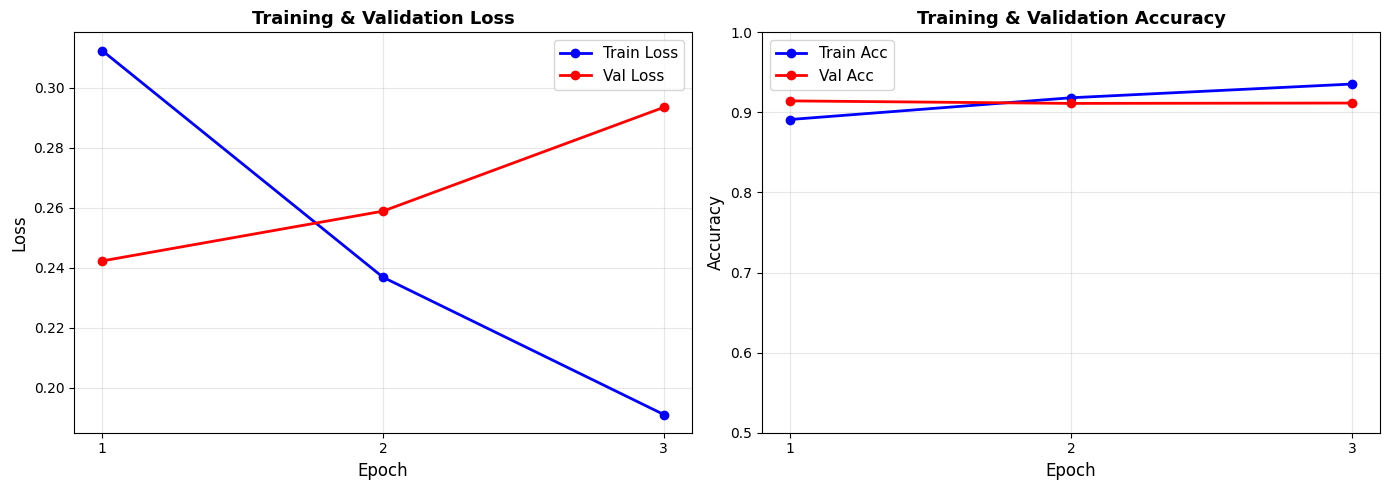

In [ ]:
# ============================================================
# CELL 17: Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# Accuracy curve
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))
axes[1].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 18: Evaluate on test set
# ============================================================

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(outputs.logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification report
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score (weighted): {f1_score(all_labels, all_preds, average='weighted'):.4f}") # Changed average to 'weighted'
print(f"\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Hate Speech', 'Offensive Language', 'Neither'])) # Corrected target_names

TEST SET EVALUATION

Accuracy: 0.9161
F1 Score (weighted): 0.9112

Detailed Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.49      0.32      0.39       130
Offensive Language       0.94      0.96      0.95      1930
           Neither       0.89      0.90      0.90       419

          accuracy                           0.92      2479
         macro avg       0.77      0.73      0.74      2479
      weighted avg       0.91      0.92      0.91      2479



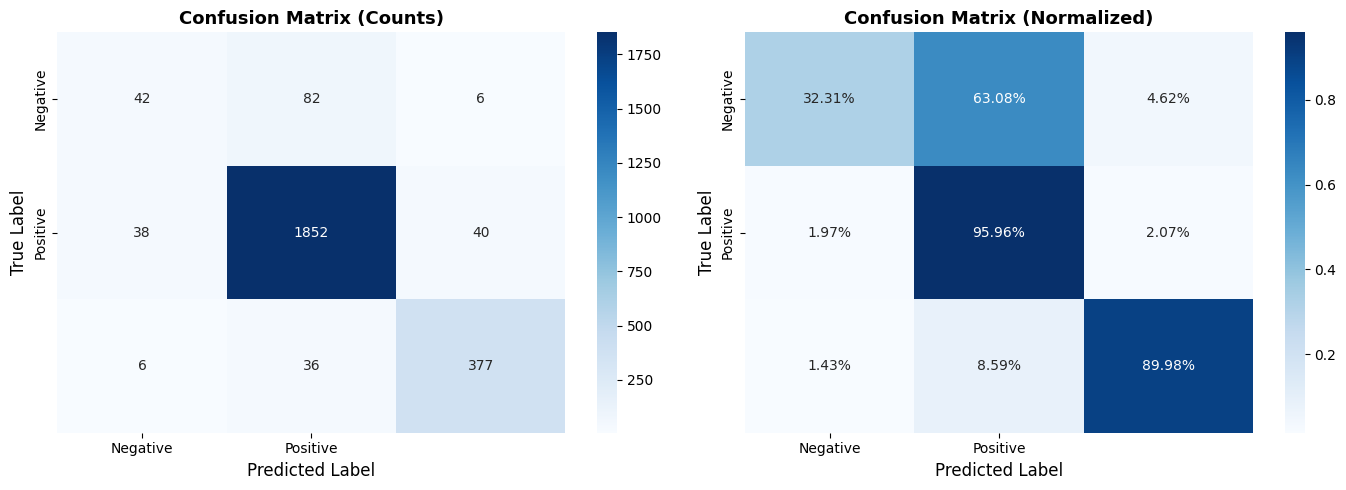

In [ ]:
# ============================================================
# CELL 19: Confusion matrix visualization
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[1])
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

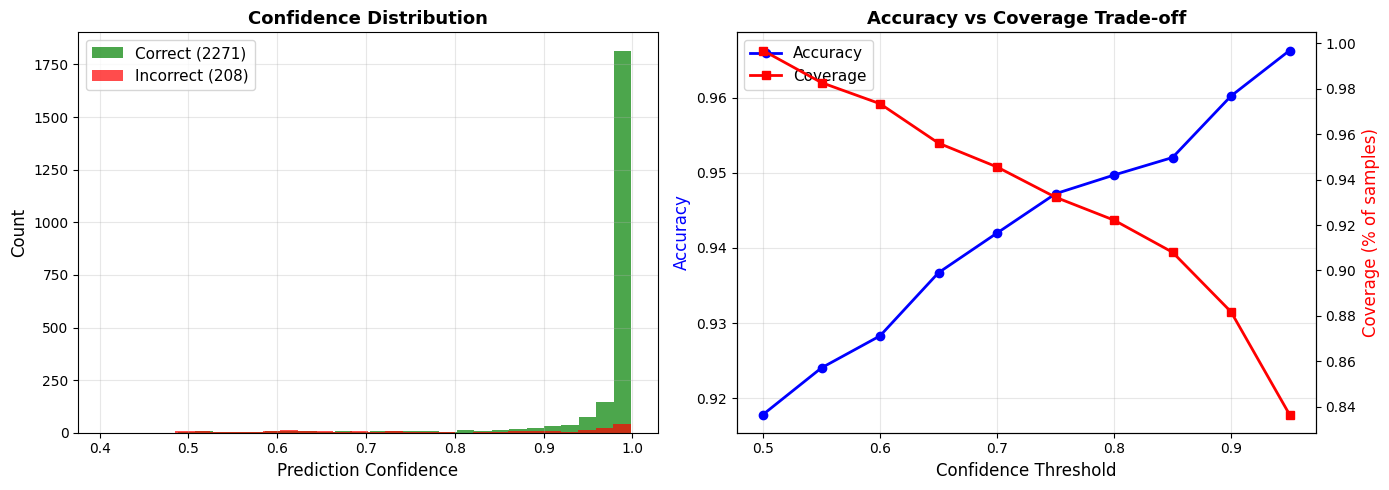


💡 Content Moderation Insight:
   Set a confidence threshold — auto-moderate high-confidence cases,
   send low-confidence cases to human reviewers.


In [ ]:
# ============================================================
# CELL 20: Confidence distribution analysis
# ============================================================

# Get confidence of predicted class
pred_confidence = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution for correct vs incorrect
axes[0].hist(pred_confidence[correct_mask], bins=30, alpha=0.7,
             label=f'Correct ({correct_mask.sum()})', color='green')
axes[0].hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy at different confidence thresholds
thresholds = np.arange(0.5, 1.0, 0.05)
accs_at_thresh = []
coverage_at_thresh = []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs_at_thresh.append(accuracy_score(all_labels[mask], all_preds[mask]))
        coverage_at_thresh.append(mask.sum() / len(mask))
    else:
        accs_at_thresh.append(0)
        coverage_at_thresh.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(thresholds, accs_at_thresh, 'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverage_at_thresh, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color='blue')
ax2.set_ylabel('Coverage (% of samples)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Content Moderation Insight:")
print("   Set a confidence threshold — auto-moderate high-confidence cases,")
print("   send low-confidence cases to human reviewers.")

In [ ]:
# ============================================================
# CELL 21: Error analysis — examine misclassified reviews
# ============================================================

# Find misclassified examples
misclassified_idx = np.where(all_preds != all_labels)[0]

print(f"Misclassified: {len(misclassified_idx)} / {len(all_labels)} "
      f"({len(misclassified_idx)/len(all_labels)*100:.1f}%)")
print("=" * 60)

# Define class names for better readability
class_names = ['Hate Speech', 'Offensive Language', 'Neither']

# Show some examples
test_texts = test_dataset.to_dict()['tweet']  # Corrected from 'text' to 'tweet'
n_show = min(5, len(misclassified_idx))
for i in range(n_show):
    idx = misclassified_idx[i]
    true_label = class_names[all_labels[idx]] # Corrected label mapping
    pred_label = class_names[all_preds[idx]]  # Corrected label mapping
    confidence = pred_confidence[idx]
    text = test_texts[int(idx)][:300]

    print(f"\n❌ Example {i+1}:")
    print(f"   True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.3f}")
    print(f"   Text: \"{text}...\"")

# Categorize errors for all classes
print(f"\n📊 Error Breakdown (per class):")
for i, class_name in enumerate(class_names):
    # False Negatives: True label is `i`, but predicted otherwise
    fn_count = np.sum((all_labels == i) & (all_preds != i))
    # False Positives: True label is not `i`, but predicted as `i`
    fp_count = np.sum((all_labels != i) & (all_preds == i))

    print(f"  Class '{class_name}':")
    print(f"    False Negatives (missed {class_name}): {fn_count}")
    print(f"    False Positives (misclassified as {class_name}): {fp_count}")



Misclassified: 208 / 2479 (8.4%)

❌ Example 1:
   True: Offensive Language | Predicted: Neither | Confidence: 0.970
   Text: "holy shit freddie highmore was in charlie and the chocolate factory me rolls on the floor laughing..."

❌ Example 2:
   True: Hate Speech | Predicted: Offensive Language | Confidence: 0.612
   Text: "these new nigga hipster hypebeasts love all these faggot ass bright colors and nike keeps giving them what they want smh..."

❌ Example 3:
   True: Offensive Language | Predicted: Neither | Confidence: 0.967
   Text: "rt cc rosemary lehmberg rt ill show you how to chug a beer motherfker..."

❌ Example 4:
   True: Neither | Predicted: Offensive Language | Confidence: 0.993
   Text: "we raided nickis wig closet for the summer bad gals just wanna have fun this bitch has the a nerve smh..."

❌ Example 5:
   True: Hate Speech | Predicted: Offensive Language | Confidence: 0.512
   Text: "when you live this gay you cant be afraid of two black dicks in your butt you fucking

In [ ]:
# ============================================================
# CELL 22: Clean up and save notebook state
# ============================================================

from ipywidgets import embed
# Or simply ensure your notebook saves widget state
import ipywidgets as widgets
widgets.Widget.close_all()